# Column Anomaly Detector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/anomaly-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/anomaly-detector/demo.ipynb)

Scan a DataFrame column-by-column for values that don't belong - **numeric outliers, null spikes, and rare categories** - and get back triaged, *explainable* alerts. Every finding names WHICH method flagged it and WHY, so a data steward can trust the alert instead of eyeballing a spreadsheet.

Fully offline - standard pandas/numpy only, no API keys.

**What this notebook covers**
1. The core detector - three complementary outlier methods + null and rare-category checks
2. A realistic sample orders table with planted anomalies
3. Running the scan and reading the triage table
4. A severity heatmap so the eye goes straight to the worst columns
5. Try-your-own-data template

## Step 1 - why three outlier methods?

No single test catches every outlier:

- **z-score** assumes a roughly Gaussian column - great for symmetric data, but a few extreme values inflate the mean and standard deviation and *hide* the very outliers we want.
- **IQR (Tukey fences)** is distribution-free - it uses quartiles, so extreme values can't move the fences.
- **MAD (modified z-score)** uses the median and median absolute deviation - the most robust of the three when a handful of huge values would swamp the others.

A value flagged by **2 or more** methods is the most trustworthy signal, so we escalate it to high severity.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

# Tunable quality bar - edit for your own tolerance.
Z_THRESH = 3.0
IQR_MULT = 1.5
MAD_THRESH = 3.5
NULL_RATE_WARN = 0.20
RARE_CATEGORY_FRAC = 0.01


@dataclass
class Anomaly:
    column: str
    method: str
    severity: str
    row: Optional[int]
    value: object
    reason: str


@dataclass
class ColumnReport:
    column: str
    dtype: str
    kind: str
    n: int
    null_rate: float
    anomalies: List[Anomaly] = field(default_factory=list)


def _severity_from_z(z: float) -> str:
    az = abs(z)
    if az >= 5:
        return "high"
    if az >= 4:
        return "medium"
    return "low"


def _numeric_anomalies(col: str, s: pd.Series) -> List[Anomaly]:
    out: List[Anomaly] = []
    vals = s.dropna()
    if len(vals) < 5 or vals.nunique() < 2:
        return out
    mean, std = vals.mean(), vals.std(ddof=0)
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - IQR_MULT * iqr, q3 + IQR_MULT * iqr
    median = vals.median()
    mad = (vals - median).abs().median()
    for idx, v in vals.items():
        methods: List[str] = []
        z = (v - mean) / std if std > 0 else 0.0
        if abs(z) > Z_THRESH:
            methods.append("zscore")
        if iqr > 0 and (v < lo_fence or v > hi_fence):
            methods.append("iqr")
        mz = 0.6745 * (v - median) / mad if mad > 0 else 0.0
        if abs(mz) > MAD_THRESH:
            methods.append("mad")
        if not methods:
            continue
        base = _severity_from_z(z if "zscore" in methods else mz)
        severity = "high" if len(methods) >= 2 and base != "low" else base
        reason = (
            f"value={v:g} vs median={median:g} (z={z:.1f}, "
            f"IQR fences=[{lo_fence:g}, {hi_fence:g}], modified-z={mz:.1f}); "
            f"flagged by {', '.join(methods)}"
        )
        out.append(Anomaly(col, "+".join(methods), severity, int(idx), v, reason))
    return out


def _categorical_anomalies(col: str, s: pd.Series) -> List[Anomaly]:
    out: List[Anomaly] = []
    vals = s.dropna().astype(str)
    n = len(vals)
    if n < 20:
        return out
    if vals.nunique() / n > 0.5:
        return out  # identifier-like column - skip
    counts = vals.value_counts()
    threshold = max(1, int(n * RARE_CATEGORY_FRAC))
    for cat, cnt in counts.items():
        if cnt <= threshold:
            frac = cnt / n
            severity = "high" if cnt == 1 else "medium" if frac < 0.005 else "low"
            reason = (
                f"category '{cat}' appears {cnt}x ({frac:.2%} of rows) - below the "
                f"{RARE_CATEGORY_FRAC:.0%} rare-value bar; possible typo or junk code"
            )
            out.append(Anomaly(col, "rare-category", severity, None, cat, reason))
    return out


def _classify(s: pd.Series) -> str:
    if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
        return "numeric"
    if pd.api.types.is_object_dtype(s) or isinstance(s.dtype, pd.CategoricalDtype):
        return "categorical"
    return "other"


def scan_column(df: pd.DataFrame, col: str) -> ColumnReport:
    s = df[col]
    n = len(s)
    null_rate = float(s.isna().mean()) if n else 0.0
    kind = _classify(s)
    report = ColumnReport(col, str(s.dtype), kind, n, null_rate)
    if null_rate >= NULL_RATE_WARN:
        sev = "high" if null_rate >= 0.5 else "medium"
        report.anomalies.append(
            Anomaly(col, "null-rate", sev, None, None,
                    f"null rate {null_rate:.1%} exceeds {NULL_RATE_WARN:.0%} bar")
        )
    if kind == "numeric":
        report.anomalies.extend(_numeric_anomalies(col, s))
    elif kind == "categorical":
        report.anomalies.extend(_categorical_anomalies(col, s))
    return report


def scan_dataframe(df: pd.DataFrame) -> List[ColumnReport]:
    if df is None or df.empty:
        return []
    return [scan_column(df, c) for c in df.columns]


def summarize(reports: List[ColumnReport]) -> pd.DataFrame:
    rows = []
    for r in reports:
        sev = {"high": 0, "medium": 0, "low": 0}
        for a in r.anomalies:
            sev[a.severity] = sev.get(a.severity, 0) + 1
        rows.append({
            "column": r.column, "kind": r.kind, "null_rate": round(r.null_rate, 3),
            "anomalies": len(r.anomalies),
            "high": sev["high"], "medium": sev["medium"], "low": sev["low"],
        })
    return pd.DataFrame(rows)


def anomalies_frame(reports: List[ColumnReport]) -> pd.DataFrame:
    rows = []
    for r in reports:
        for a in r.anomalies:
            rows.append({
                "column": a.column, "method": a.method, "severity": a.severity,
                "row": a.row, "value": a.value, "reason": a.reason,
            })
    cols = ["column", "method", "severity", "row", "value", "reason"]
    return pd.DataFrame(rows, columns=cols)

print("Detector loaded.")

Detector loaded.


## Step 2 - a sample orders table with planted anomalies

So you can see the detector earn its keep, we build a 300-row orders table and deliberately plant:

- a **fat-finger / fraud spike** and an **impossible negative** in `order_amount`
- an **impossible age** (199) in `customer_age`
- two **typo / junk** region codes (`Nrth`, `XX`)
- a **null spike** in `email`

In [2]:
def make_sample_data(seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = 300
    amount = rng.normal(120, 30, n).round(2)
    amount[7] = 9999.0      # fat-finger / fraud spike
    amount[150] = -50.0     # impossible negative
    amount[298] = 1500.0    # milder high outlier
    age = rng.integers(18, 70, n).astype(float)
    age[42] = 199.0         # bad age
    region = rng.choice(["North", "South", "East", "West"], n, p=[.3, .3, .25, .15]).astype(object)
    region[10] = "Nrth"     # typo -> rare category
    region[11] = "XX"       # junk code -> rare category
    email = np.array([f"user{i}@shop.com" for i in range(n)], dtype=object)
    email[np.array([3, 20, 55, 90, 130, 200, 250, 275])] = None  # null spike
    return pd.DataFrame({
        "order_amount": amount, "customer_age": age, "region": region, "email": email,
    })

df = make_sample_data()
df.head()

,order_amount,customer_age,region,email
0,129.14,49.0,West,user0@shop.com
1,88.80,30.0,South,user1@shop.com
2,142.51,35.0,South,user2@shop.com
3,148.22,37.0,East,None
4,61.47,44.0,East,user4@shop.com


## Step 3 - scan and read the triage table

`summarize()` gives one row per column with counts by severity - the steward's at-a-glance triage view. `email` is an identifier-like column, so no rare-category noise, but its null spike is still caught.

In [3]:
reports = scan_dataframe(df)
summary = summarize(reports)
summary

,column,kind,null_rate,anomalies,high,medium,low
0,order_amount,numeric,0.000,7,3,0,4
1,customer_age,numeric,0.000,1,1,0,0
2,region,categorical,0.000,2,2,0,0
3,email,categorical,0.027,0,0,0,0


### The individual findings, most severe first

Every row is explainable: it says which method(s) fired and the exact numbers behind the call. Consensus across methods (e.g. `zscore+iqr+mad`) is the strongest signal.

In [4]:
flat = anomalies_frame(reports).sort_values(
    "severity", key=lambda s: s.map({"high": 0, "medium": 1, "low": 2})
)
flat.head(8)

,column,method,severity,row,value,reason
0,order_amount,zscore+iqr+mad,high,7.0,9999.0,"value=9999 vs median=118.445 (z=17.1, IQR fenc..."
2,order_amount,iqr+mad,high,150.0,-50.0,"value=-50 vs median=118.445 (z=-0.4, IQR fence..."
6,order_amount,iqr+mad,high,298.0,1500.0,"value=1500 vs median=118.445 (z=2.3, IQR fence..."
7,customer_age,zscore+iqr+mad,high,42.0,199.0,"value=199 vs median=46 (z=8.6, IQR fences=[-12..."
8,region,rare-category,high,NaN,Nrth,category 'Nrth' appears 1x (0.33% of rows) - b...
9,region,rare-category,high,NaN,XX,category 'XX' appears 1x (0.33% of rows) - bel...
1,order_amount,iqr,low,139.0,207.42,"value=207.42 vs median=118.445 (z=0.1, IQR fen..."
3,order_amount,iqr,low,226.0,195.52,"value=195.52 vs median=118.445 (z=0.1, IQR fen..."


## Step 4 - a severity heatmap

A quick visual so the eye lands on the worst columns first. Each cell is the count of findings at that severity.

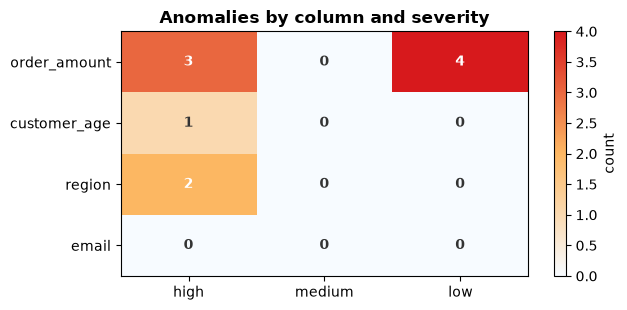

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

mat = summary.set_index("column")[["high", "medium", "low"]]
cmap = LinearSegmentedColormap.from_list("sev", ["#f7fbff", "#fdb863", "#d7191c"])

fig, ax = plt.subplots(figsize=(6.5, 3.2))
im = ax.imshow(mat.values, cmap=cmap, aspect="auto")
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(mat.columns)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v >= 2 else "#333", fontweight="bold")
ax.set_title("Anomalies by column and severity", fontweight="bold")
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.savefig("severity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

The detector caught **every planted anomaly** without hand-tuning:

| Column | Caught |
|--------|--------|
| `order_amount` | 9999 spike, -50 negative, 1500 high outlier (2-3 methods each) |
| `customer_age` | age 199 (all three methods) |
| `region` | `Nrth` typo + `XX` junk code (rare category) |
| `email` | null spike caught; not flagged as rare-category (identifier-like, auto-skipped) |

The value is not just the flag - it's the **reason** attached to each one, which turns a data-quality alert from "trust me" into "here's the evidence."

## Try your own data

Point it at any CSV and read the same two tables. Uncomment and edit:

In [6]:
# my_df = pd.read_csv("your_data.csv")
# my_reports = scan_dataframe(my_df)
# display(summarize(my_reports))
# display(anomalies_frame(my_reports).sort_values(
#     "severity", key=lambda s: s.map({"high": 0, "medium": 1, "low": 2})).head(20))

# Tune the bar at the top of the notebook:
#   Z_THRESH / IQR_MULT / MAD_THRESH  -> numeric strictness
#   NULL_RATE_WARN                    -> how much missingness is acceptable
#   RARE_CATEGORY_FRAC                -> how rare a category must be to flag

---
Part of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio - Day 91, Data Quality & Governance Suite.

For the interactive app: `streamlit run app.py` in this folder. It lets you upload a CSV (or use this sample), scan, and triage findings by severity.